# This is a broker metrics related forecasting analysis for the metrics:

### query/bytes 
### query/cpu/time 
### query/node/bytes 
### query/node/time 
### query/node/ttfb 
### query/priority 
### query/time

In [70]:
from pydruid.client import *
from pydruid.utils import dimensions, filters, aggregators
import pandas as pd

In [71]:
query = PyDruid('http://test0.druidonk8s.druid.data-infra.shopee.io/', 'druid/v2')
query.set_basic_auth_credentials("admin", "s2Ysn5v5")

In [72]:
ts = query.timeseries(
    datasource='druid_cenarius_metrics_all',
    granularity='day',
    intervals='2022-07-01/2022-08-03',
    #paging_spec={'pagingIdentifies': {}, 'threshold': 1},
    #context={"timeout": 1000},
    aggregations={'maxval': aggregators.longmax('value')},
    filter=(filters.Dimension('metric') == 'query/time') & (filters.Dimension('service') == 'druid/broker')
)
df = query.export_pandas()
df['ds'] = pd.to_datetime(df['timestamp']).dt.date
df.drop(columns=['timestamp'])
df = df.rename(columns={"maxval":"y"})

In [73]:
from prophet import Prophet

m = Prophet()
m.fit(df)

14:30:59 - cmdstanpy - INFO - Chain [1] start processing
14:30:59 - cmdstanpy - INFO - Chain [1] done processing


In [74]:
future = m.make_future_dataframe(periods=60)
future.tail()

,ds
71,2022-09-27
72,2022-09-28
73,2022-09-29
74,2022-09-30
75,2022-10-01


In [75]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
71,2022-09-27,8.970063e+06,-1.390934e+06,2.054906e+07
72,2022-09-28,-1.165177e+06,-1.210805e+07,9.430264e+06
73,2022-09-29,-1.165704e+06,-1.210700e+07,1.002112e+07
74,2022-09-30,-1.167057e+06,-1.110361e+07,9.441040e+06
75,2022-10-01,-1.168187e+06,-1.200228e+07,9.610536e+06


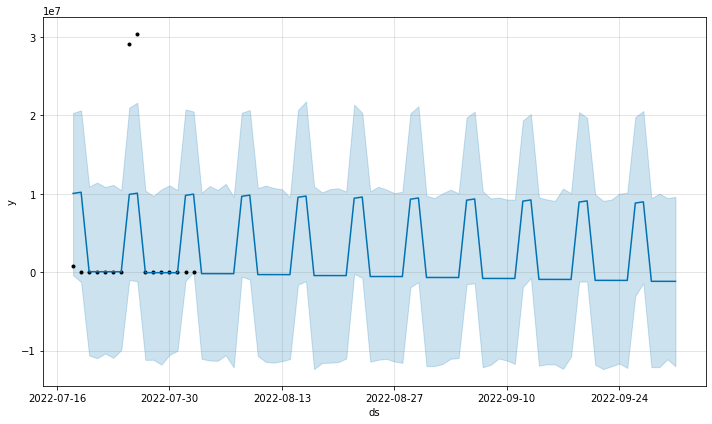

In [76]:
fig1 = m.plot(forecast)


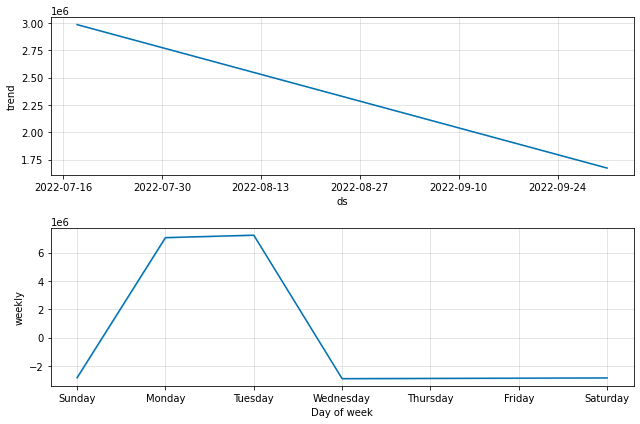

In [77]:
fig2 = m.plot_components(forecast)

In [78]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

In [79]:
plot_components_plotly(m, forecast)